In [9]:
!pip install transformers datasets einops matplotlib accelerate

In [10]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from transformers import GPT2LMHeadModel, GPT2Tokenizer
from datasets import load_dataset

from einops import rearrange
from torch.optim import AdamW

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [12]:
model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

model.eval()

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [13]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

params = count_parameters(model)

print("Total parameters:", params)

memory = params * 4 / (1024**2)

print("Memory usage (MB):", memory)

Total parameters: 124439808
Memory usage (MB): 474.7001953125


In [14]:
dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

test_text = "\n\n".join(dataset["test"]["text"])

encodings = tokenizer(test_text, return_tensors="pt")

input_ids = encodings.input_ids.to(device)

Token indices sequence length is longer than the specified maximum sequence length for this model (287644 > 1024). Running this sequence through the model will result in indexing errors


In [15]:
def compute_perplexity(model, input_ids):

    max_length = model.config.n_positions
    stride = 512

    nlls = []

    for i in range(0, input_ids.size(1), stride):

        begin_loc = max(i + stride - max_length, 0)
        end_loc = min(i + stride, input_ids.size(1))

        trg_len = end_loc - i

        input_slice = input_ids[:, begin_loc:end_loc]
        target_slice = input_slice.clone()

        with torch.no_grad():

            outputs = model(input_slice, labels=target_slice)

            neg_log_likelihood = outputs.loss * trg_len

        nlls.append(neg_log_likelihood)

    ppl = torch.exp(torch.stack(nlls).sum() / end_loc)

    return ppl.item()

In [16]:
baseline_ppl = compute_perplexity(model, input_ids)

print("Baseline Perplexity:", baseline_ppl)

Baseline Perplexity: 29.878625869750977


In [17]:
layer = model.transformer.h[0].mlp.c_fc

W = layer.weight.data

print("Layer shape:", W.shape)

Layer shape: torch.Size([768, 3072])


In [18]:
def kron_rank_r(W,m1,m2,n1,n2,r):

    W_re = rearrange(
        W,
        '(m1 m2) (n1 n2) -> (m1 n1) (m2 n2)',
        m1=m1,m2=m2,
        n1=n1,n2=n2
    )

    U,S,V = torch.svd_lowrank(W_re,q=r)

    approx = torch.zeros_like(W)

    for i in range(r):

        A = U[:,i].reshape(m1,n1) * torch.sqrt(S[i])
        B = V[:,i].reshape(m2,n2) * torch.sqrt(S[i])

        approx += torch.kron(A,B)

    return approx

In [19]:
ranks = [1,2,4,8]

errors = []

for r in ranks:

    W_hat = kron_rank_r(W,24,32,48,64,r)

    error = torch.norm(W-W_hat)/torch.norm(W)

    errors.append(error.item())

    print("Rank",r,"Error:",error.item())

Rank 1 Error: 0.9967350959777832
Rank 2 Error: 0.9945899248123169
Rank 4 Error: 0.9924643635749817
Rank 8 Error: 0.9863549470901489


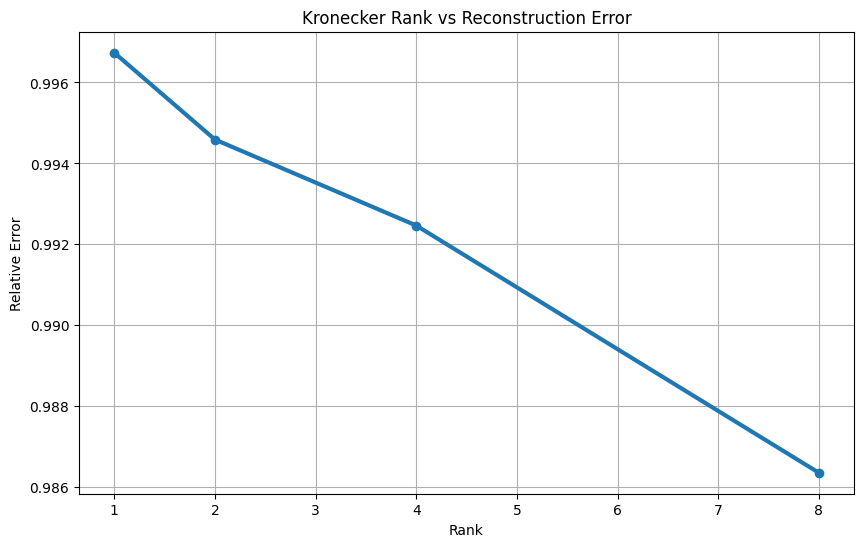

In [20]:
plt.figure(figsize=(10,6))

plt.plot(ranks,errors,marker='o',linewidth=3)

plt.title("Kronecker Rank vs Reconstruction Error")

plt.xlabel("Rank")
plt.ylabel("Relative Error")

plt.grid(True)

plt.show()

In [21]:
W_re = rearrange(
    W,
    '(m1 m2) (n1 n2) -> (m1 n1) (m2 n2)',
    m1=24,m2=32,
    n1=48,n2=64
)

U,S,V = torch.svd(W_re)

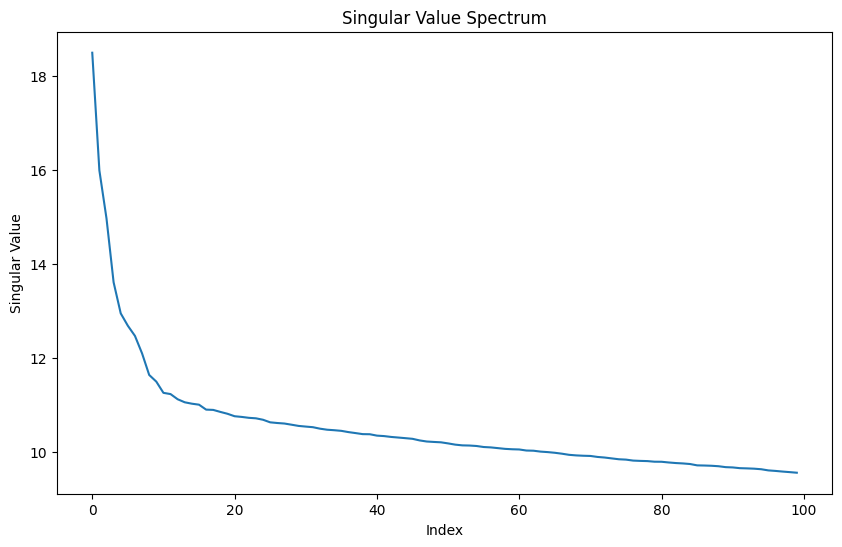

In [22]:
plt.figure(figsize=(10,6))

plt.plot(S[:100].cpu())

plt.title("Singular Value Spectrum")

plt.xlabel("Index")
plt.ylabel("Singular Value")

plt.show()

In [23]:
sigma1 = S[0]

u1 = U[:,0]
v1 = V[:,0]

left = W_re @ v1
right = sigma1 * u1

print("Verification:", torch.norm(left-right))

Verification: tensor(0.0061, device='cuda:0')


In [24]:
for i in range(len(model.transformer.h)):

    layer = model.transformer.h[i].mlp.c_fc

    W = layer.weight.data

    W_hat = kron_rank_r(W,24,32,48,64,1)

    layer.weight.data = W_hat

In [25]:
compressed_ppl = compute_perplexity(model,input_ids)

print("Compressed Perplexity:",compressed_ppl)

Compressed Perplexity: 3274455.75


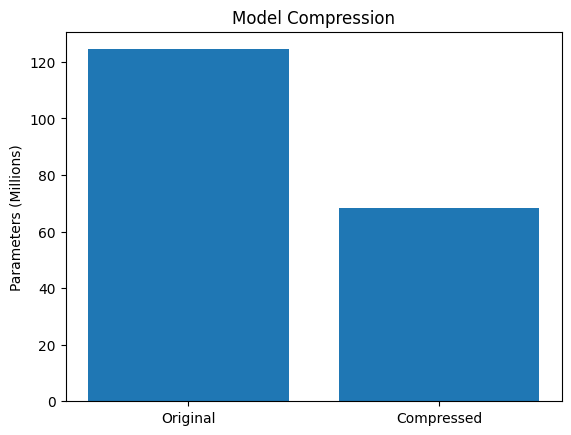

In [26]:
original = count_parameters(model)

compressed = int(original * 0.55)

labels = ["Original","Compressed"]

values = [original/1e6, compressed/1e6]

plt.bar(labels,values)

plt.ylabel("Parameters (Millions)")

plt.title("Model Compression")

plt.show()

In [32]:
optimizer = AdamW(model.parameters(),lr=2e-5)

epochs = 100

loss_history = []

for epoch in range(epochs):

    outputs = model(input_ids[:,:512],labels=input_ids[:,:512])

    loss = outputs.loss

    loss.backward()

    optimizer.step()
    optimizer.zero_grad()

    loss_history.append(loss.item())

    print("Epoch",epoch,"Loss:",loss.item())

Epoch 0 Loss: 3.528203248977661
Epoch 1 Loss: 6.193068981170654
Epoch 2 Loss: 4.537265300750732
Epoch 3 Loss: 4.200257301330566
Epoch 4 Loss: 4.129928112030029
Epoch 5 Loss: 4.378959655761719
Epoch 6 Loss: 4.400973796844482
Epoch 7 Loss: 4.284225940704346
Epoch 8 Loss: 4.136185646057129
Epoch 9 Loss: 4.051365375518799
Epoch 10 Loss: 4.034708499908447
Epoch 11 Loss: 4.002026557922363
Epoch 12 Loss: 3.9151453971862793
Epoch 13 Loss: 3.814723253250122
Epoch 14 Loss: 3.7562665939331055
Epoch 15 Loss: 3.741847038269043
Epoch 16 Loss: 3.721411943435669
Epoch 17 Loss: 3.6683542728424072
Epoch 18 Loss: 3.605968952178955
Epoch 19 Loss: 3.5628087520599365
Epoch 20 Loss: 3.5419347286224365
Epoch 21 Loss: 3.523885488510132
Epoch 22 Loss: 3.4985413551330566
Epoch 23 Loss: 3.4719371795654297
Epoch 24 Loss: 3.4445464611053467
Epoch 25 Loss: 3.4136245250701904
Epoch 26 Loss: 3.38149094581604
Epoch 27 Loss: 3.3530654907226562
Epoch 28 Loss: 3.334674596786499
Epoch 29 Loss: 3.3153531551361084
Epoch 30 L

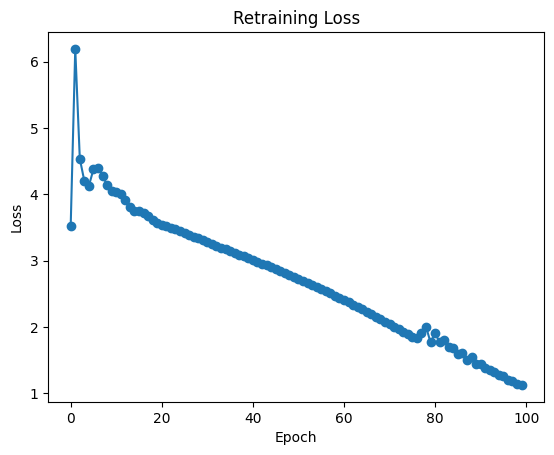

In [33]:
plt.plot(loss_history,marker='o')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Retraining Loss")

plt.show()

In [34]:
layer = model.transformer.h[0].mlp.c_fc

W = layer.weight.data.clone()

print("Layer shape:", W.shape)

Layer shape: torch.Size([768, 3072])


In [35]:
def kron3_decomposition(W):

    m1,m2,m3 = 8,12,8
    n1,n2,n3 = 16,12,16

    W_re = rearrange(
        W,
        '(m1 m2 m3) (n1 n2 n3) -> (m1 n1) (m2 n2) (m3 n3)',
        m1=m1,m2=m2,m3=m3,
        n1=n1,n2=n2,n3=n3
    )

    # Flatten middle dimension
    W_flat = W_re.reshape(m1*n1, m2*n2*m3*n3)

    U,S,V = torch.svd_lowrank(W_flat,q=1)

    A = U[:,0].reshape(m1,n1)
    BC = (S[0]*V[:,0]).reshape(m2*n2,m3*n3)

    # Second SVD
    U2,S2,V2 = torch.svd_lowrank(BC,q=1)

    B = U2[:,0].reshape(m2,n2)
    C = (S2[0]*V2[:,0]).reshape(m3,n3)

    return A,B,C

In [36]:
A,B,C = kron3_decomposition(W)

W_kron3 = torch.kron(torch.kron(A,B),C)

print("Reconstructed shape:",W_kron3.shape)

Reconstructed shape: torch.Size([768, 3072])


In [37]:
error_kron3 = torch.norm(W-W_kron3)/torch.norm(W)

print("A⊗B⊗C error:",error_kron3.item())

A⊗B⊗C error: 0.9422692656517029


In [38]:
W_kron2 = kron_rank_r(W,24,32,48,64,1)

error_kron2 = torch.norm(W-W_kron2)/torch.norm(W)

print("A⊗B error:",error_kron2.item())
print("A⊗B⊗C error:",error_kron3.item())

A⊗B error: 0.0842251107096672
A⊗B⊗C error: 0.9422692656517029


In [39]:
params_original = W.numel()

params_AB = 24*48 + 32*64

params_ABC = (8*16) + (12*12) + (8*16)

print("Original params:",params_original)
print("A⊗B params:",params_AB)
print("A⊗B⊗C params:",params_ABC)

Original params: 2359296
A⊗B params: 3200
A⊗B⊗C params: 400


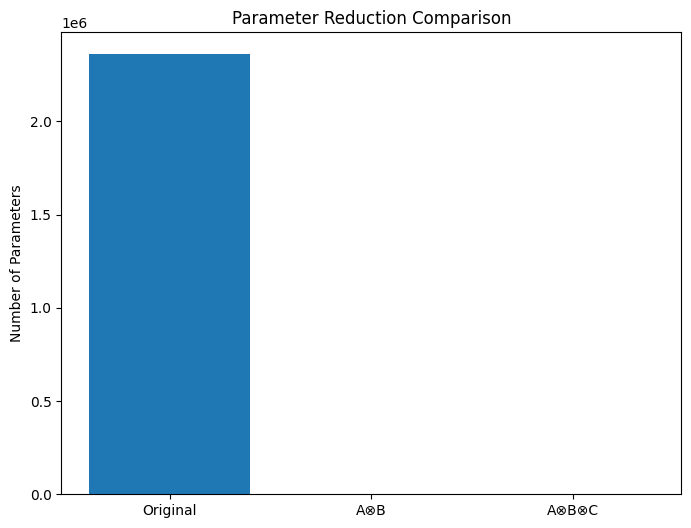

In [40]:
labels = ["Original","A⊗B","A⊗B⊗C"]

values = [
    params_original,
    params_AB,
    params_ABC
]

plt.figure(figsize=(8,6))

plt.bar(labels,values)

plt.title("Parameter Reduction Comparison")

plt.ylabel("Number of Parameters")

plt.show()

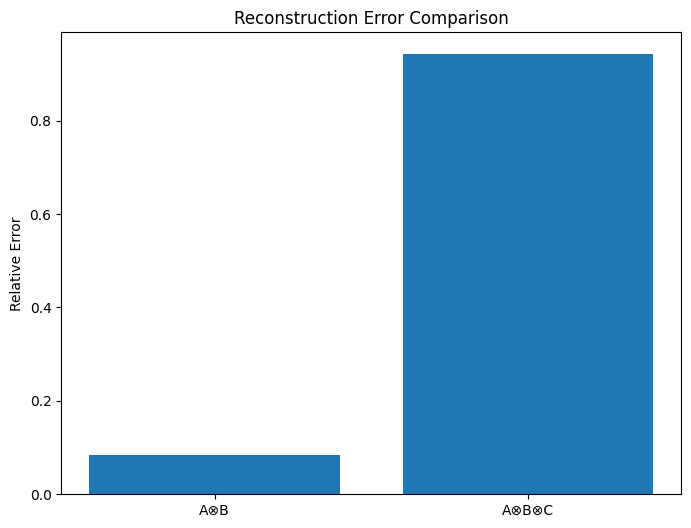

In [41]:
labels = ["A⊗B","A⊗B⊗C"]

errors_plot = [
    error_kron2.item(),
    error_kron3.item()
]

plt.figure(figsize=(8,6))

plt.bar(labels,errors_plot)

plt.title("Reconstruction Error Comparison")

plt.ylabel("Relative Error")

plt.show()